In [1]:
import matplotlib.pyplot as plt
import numpy as np

In [ ]:
# Define learn function
# deg is the highest degree of the function. Ex cubic function is 3
def learn(alpha, num_epoch, deg, x_train, y_train):
    x_train = np.array(x_train)
    weight_history = []
    error_history = []
    num_params = 1 + deg * len(x_train[1])
    print("Shape")
    print(np.shape(x_train))

    # Each row of the weights corresponds to the degree (x^0, x^1, etc)
    # Each column correspoonds to an input variable column (first input column, second input column)
    weights_num_cols = np.shape(x_train)[1]
    weights_num_rows = deg + 1
    weights = np.zeros(shape=(weights_num_rows, weights_num_cols))
    w = 0
    while w < weights_num_cols and w < weights_num_rows:
        weights[w][w] = 1
        w = w + 1

    rand_adds = np.zeros_like(weights)
    rand_adds = np.random.random(np.shape(weights)) / 10 - 0.05
    weights = weights + rand_adds
    

    print("Weights shape: ", np.shape(weights))
    j = 0

    printed = False

    while j < num_epoch:
        # Calculate sum of loss
        loss_sum = 0
        for n in range(len(x_train)):
            exp_input_n = np.array([x_train[n] ** i for i in range(deg + 1)]) # The first row is for the bias value
            weighted_input_n = np.array(weights * exp_input_n)
            pred_val = np.sum(weighted_input_n) 
            loss = (y_train[n] - pred_val) * exp_input_n # A vector of loss for each parameter (weight and bias)

            loss_sum = loss_sum + loss

            if not printed:
                print(f"init weights: {weights}")
                print(f"x_train[n]: {x_train[n]}")
                print(f"exp_input_n: {exp_input_n}")
                print(f"weighted_input_n: {weighted_input_n}")
                print(f"pred_val: {pred_val}")
                print(f"loss: {loss}")
                print(f"loss_sum: {loss_sum}")
                printed = True

        error_history.append(np.sum(loss_sum))
        # Update theta
        weights = weights + alpha * loss_sum
        weight_history.append(weights)

        if j == 0:
            print(f"weights: {weights}")
            print(f"error_history: {error_history}")
            print(f"weight_history: {weight_history}")

        j = j + 1
    
    return weights, weight_history, error_history, loss_sum


In [3]:
def printModelData(data_inputs, data_y, weights, title):
    plt.scatter(data_inputs, data_y)
    x_space = np.linspace(np.min(data_inputs), np.max(data_inputs))
    num_weights = weights.shape[1] #Or 1?
    print(f'Num weights is {num_weights}')
    sample = np.array([1, 3])
    print(f'Sample result is f([1, 3]) = {np.sum(weights * [[sample ** i] for i in range(num_weights)])}')
    print(f'Step 1: {[[sample ** i] for i in range(num_weights)]}')
    print(f'Step 2: {weights * [[sample ** i] for i in range(num_weights)]}')
    print(f'Sample result is f(1) = {np.sum(weights * [[1 ** i] for i in range(num_weights)])}')
    model_predictions_sing_var =  [np.sum(weights * [x ** i for i in range(num_weights)]) for x in x_space]
    model_predictions_all_var =  [np.sum(weights * [x ** i for i in range(num_weights)]) for x in data_inputs]



    deg = weights.size - 1 # Linear has degree of 1
    x_space = np.linspace([0,0], np.max[10, 10])
    exp_input_n = [[x ** i for i in range(deg + 1)] for x in x_space] # The first row is for the bias value
    exp_input_n = np.array(exp_input_n)
    print("\nExp input n", exp_input_n)
    weighted_input_n = np.array(weights * exp_input_n)
    print("Weighted Exp input n", weighted_input_n)

    # input_n = np.array([x_train[n] ** i for i in range(num_params)]) 
    pred_val = np.sum(weighted_input_n) 

    # plt.plot(x_space, model_predictions)
    plt.title(title)
    plt.show()

In [4]:
def showHistory(history, title):
    history = np.array(history)
    plt.scatter([i for i in range(0, len(history))], history)
    plt.title(title)
    plt.show()

Shape
(3, 1)
Weights shape:  (2, 1)
init weights: [[0.04555357]
 [0.05491306]]
x_train[n]: [1]
exp_input_n: [[1]
 [1]]
weighted_input_n: [[0.04555357]
 [0.05491306]]
pred_val: 0.10046663030030098
loss: [2.89953337]
loss_sum: [2.89953337]
weights: [[0.07851146]
 [0.08787096]]
error_history: [np.float64(32.957895705472346)]
weight_history: [array([[0.07851146],
       [0.08787096]])]
WEIGHTS: [[1.69344835]
 [1.70280785]]


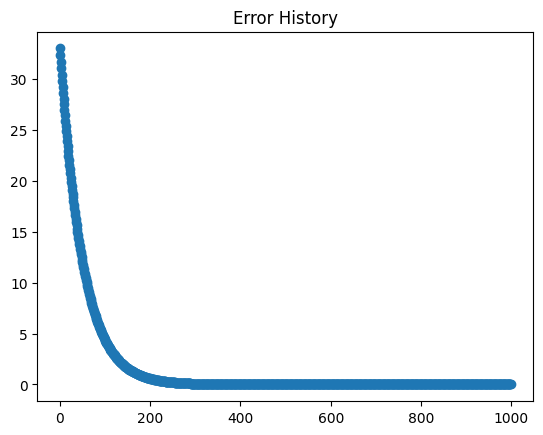

Last error: 5.659905077948224e-08
[[[0.07851146]
  [0.08787096]]

 [[0.1108102 ]
  [0.1201697 ]]

 [[0.14246296]
  [0.15182246]]

 ...

 [[1.69344835]
  [1.70280785]]

 [[1.69344835]
  [1.70280785]]

 [[1.69344835]
  [1.70280785]]]


ValueError: x and y must be the same size

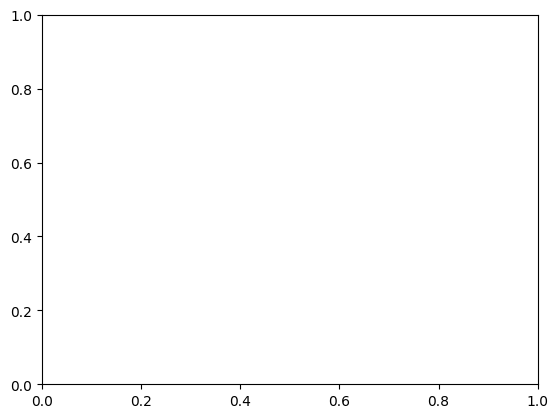

In [7]:
# Test learn function with 1 column
xs = [1, 2, 3]
example_x = np.array([[1], [2], [3]]) # Shape (3, 2)
example_y = np.array([[1 + 2], [1 + 4], [1 + 6]])
# Solution: y = 1 + 2 * xsub0

weights, weight_history, error_history, loss_sum = learn(0.001, 1000, 1, example_x, example_y)
print(f"WEIGHTS: {weights}")
# printModelData(test_x[:, 0], test_y, weights, "Test data")
showHistory(error_history, "Error History")
print(f"Last error: {error_history[len(error_history) - 1]}")
weight_history = np.array(weight_history)
print(weight_history)
showHistory(weight_history, "Weight History")

# sample = np.array([1,3])
# deg = 1
# exp_input_n = [sample ** i for i in range(deg + 1)] # The first row is for the bias value
# exp_input_n = np.array(exp_input_n)
# print("\nExp input n", exp_input_n)
# weighted_input_n = np.array(weights * exp_input_n)
# print("Weighted Exp input n", weighted_input_n)
# pred_val = np.sum(weighted_input_n) 
# print(pred_val)

# # print solution
# ax = plt.figure().add_subplot(projection='3d')
# x1 = example_x[:,0]
# x2 = example_x[:,1]
# ax.scatter(x1, x2, zs=example_y.flatten(), zdir='z', c= 'b', label='curve in (x, y)')
# # colors = ('r', 'g', 'b', 'k')
# # np.random.seed(19680801)
# # x = np.random.sample(20 * len(colors))
# # y = np.random.sample(20 * len(colors))
# # c_list = []
# # for c in colors:
#     # c_list.extend([c] * 20)
# pred_vals = []
# for sample in example_x:
#     exp_input_n = np.array(sample)
#     weighted_input_n = np.array(weights * exp_input_n)
#     pred_vals.append(np.sum(weighted_input_n) )
# print(pred_vals)
# ax.scatter(x1, x2, zs=pred_vals, c='r', label='points in (x, z)')
# ax.legend()
# ax.set_xlabel('X')
# ax.set_ylabel('Y')
# ax.set_zlabel('Z')

# Customize the view angle so it's easier to see that the scatter points lie
# on the plane y=0
ax.view_init(elev=20., azim=-35, roll=0)
plt.show()

Shape
(3, 2)
Weights shape:  (2, 2)
init weights: [[0.09851001 0.09851001]
 [0.07624479 0.07624479]]
x_train[n]: [1 3]
exp_input_n: [[1 1]
 [1 3]]
weighted_input_n: [[0.09851001 0.09851001]
 [0.07624479 0.22873436]]
pred_val: 0.5019991646825218
loss: [ 5.49800084 16.49400251]
loss_sum: [ 5.49800084 16.49400251]
weights: [[0.16166814 0.25263407]
 [0.13940292 0.23036885]]
error_history: [np.float64(217.28218978167558)]
weight_history: [array([[0.16166814, 0.25263407],
       [0.13940292, 0.23036885]])]
WEIGHTS: [[0.83990473 1.30156794]
 [0.81763951 1.27930272]]


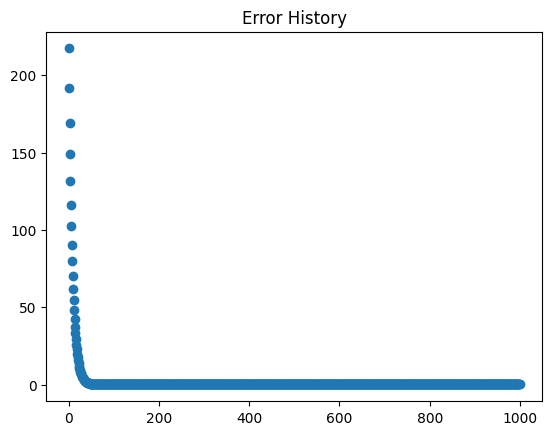

Last error: 0.1039591750028599

Exp input n [[1 1]
 [1 3]]
Weighted Exp input n [[0.83990473 1.30156794]
 [0.81763951 3.83790816]]
6.79702034168753
[np.float64(9.400156225292932), np.float64(16.21944178784056), np.float64(23.038727350388186)]


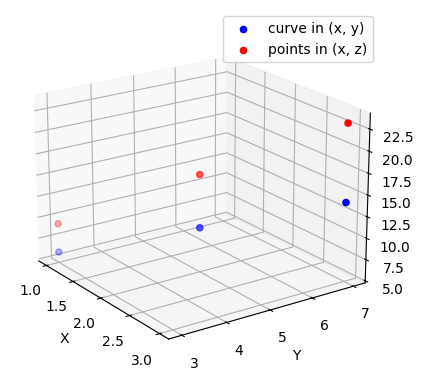

In [ ]:
# Test learn function with 2 columns
xs = [1, 2, 3]
example_x = np.array([[1, 3], [2, 5], [3, 7]]) # Shape (3, 2)
example_y = np.array([[3 + 3], [5 + 5], [7 + 7]])
# Solution: y = 1 + 2 * xsub0 + 1 * xsub1

weights, weight_history, error_history, loss_sum = learn(0.001, 1000, 1, example_x, example_y)
print(f"WEIGHTS: {weights}")
# printModelData(test_x[:, 0], test_y, weights, "Test data")
showHistory(error_history, "Error History")
print(f"Last error: {error_history[len(error_history) - 1]}")
weight_history = np.array(weight_history)
# showHistory(weight_history[:, 0], "Weight History")

sample = np.array([1,3])
deg = 1
exp_input_n = [sample ** i for i in range(deg + 1)] # The first row is for the bias value
exp_input_n = np.array(exp_input_n)
print("\nExp input n", exp_input_n)
weighted_input_n = np.array(weights * exp_input_n)
print("Weighted Exp input n", weighted_input_n)
pred_val = np.sum(weighted_input_n) 
print(pred_val)

# print solution
ax = plt.figure().add_subplot(projection='3d')
x1 = example_x[:,0]
x2 = example_x[:,1]
ax.scatter(x1, x2, zs=example_y.flatten(), zdir='z', c= 'b', label='curve in (x, y)')
# colors = ('r', 'g', 'b', 'k')
# np.random.seed(19680801)
# x = np.random.sample(20 * len(colors))
# y = np.random.sample(20 * len(colors))
# c_list = []
# for c in colors:
    # c_list.extend([c] * 20)
pred_vals = []
for sample in example_x:
    exp_input_n = np.array(sample)
    weighted_input_n = np.array(weights * exp_input_n)
    pred_vals.append(np.sum(weighted_input_n) )
print(pred_vals)
ax.scatter(x1, x2, zs=pred_vals, c='r', label='points in (x, z)')
ax.legend()
ax.set_xlabel('X')
ax.set_ylabel('Y')
ax.set_zlabel('Z')

# Customize the view angle so it's easier to see that the scatter points lie
# on the plane y=0
ax.view_init(elev=20., azim=-35, roll=0)
plt.show()

# Part 2

Gen AI: I used Chat GPT to understand what a basis function is when used in the context of Machine Learning. 

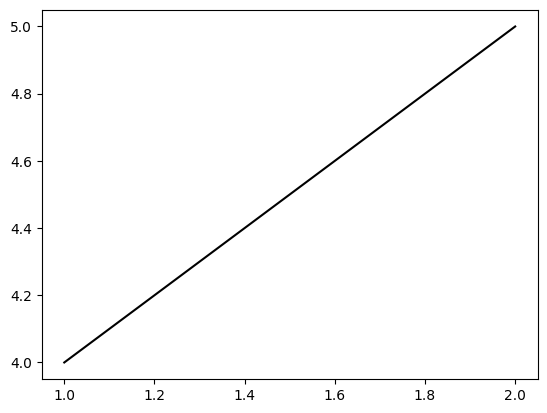

In [ ]:

first_x = 1
last_x = 2
bias = 3
learned_slope = 1
plt.plot([first_x, last_x], [bias + first_x * learned_slope, bias + last_x * learned_slope], color="black")
plt.show()

In [ ]:
data_formats = {'names': ('id', 'baths', 'land', 'living', 'garages', 'rooms','beds','age', 'price'), 'formats':('i2', 'f2', 'f4','f4', 'f4', 'i4', 'i4','i4','f8')}
housing_train = np.loadtxt("train.csv", delimiter=',', skiprows=1, dtype=data_formats)
housing_test = np.loadtxt("test.csv", delimiter=',', skiprows=1, dtype=data_formats)
#House ID,Bathrooms,Land Area,Living area,# Garages,# Rooms,# Bedrooms,Age of home,Price

housing_train_output = housing_train["price"]

housing_train_input = [0] * len(housing_train)
for i, row in enumerate(housing_train):
    row = np.array([row[0], row[1], row[2], row[3], row[4], row[5], row[6], row[7]])
    housing_train_input[i] = row

housing_train_input = np.array(housing_train_input)
print(np.shape(housing_train_input))

(20, 8)


Shape
(20, 8)
Weights shape:  (2, 8)
init weights: [[0.03131592 0.03131592 0.03131592 0.03131592 0.03131592 0.03131592
  0.03131592 0.03131592]
 [0.07526595 0.07526595 0.07526595 0.07526595 0.07526595 0.07526595
  0.07526595 0.07526595]]
x_train[n]: [ 1.          1.          3.47199988  0.99800003  1.          7.
  4.         42.        ]
exp_input_n: [[ 1.          1.          1.          1.          1.          1.
   1.          1.        ]
 [ 1.          1.          3.47199988  0.99800003  1.          7.
   4.         42.        ]]
weighted_input_n: [[0.03131592 0.03131592 0.03131592 0.03131592 0.03131592 0.03131592
  0.03131592 0.03131592]
 [0.07526595 0.07526595 0.26132336 0.07511542 0.07526595 0.52686164
  0.30106379 3.16116981]]
pred_val: 4.801859261614967
loss: [  491755.19814074   491755.19814074  1707373.99072978   490771.70040676
   491755.19814074  3442286.38698517  1967020.79256295 20653718.32191101]
loss_sum: [  491755.19814074   491755.19814074  1707373.99072978   490771

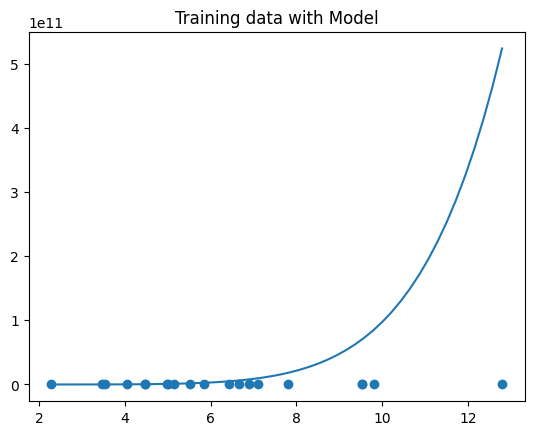

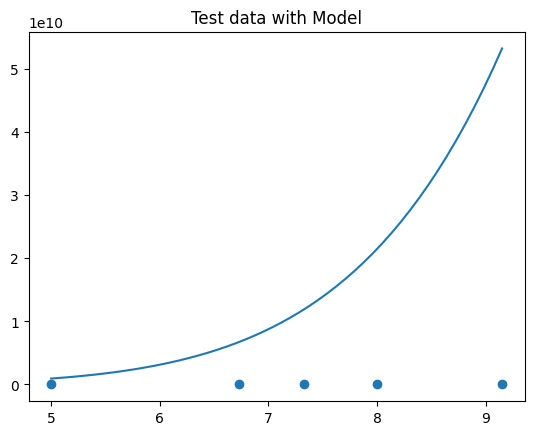

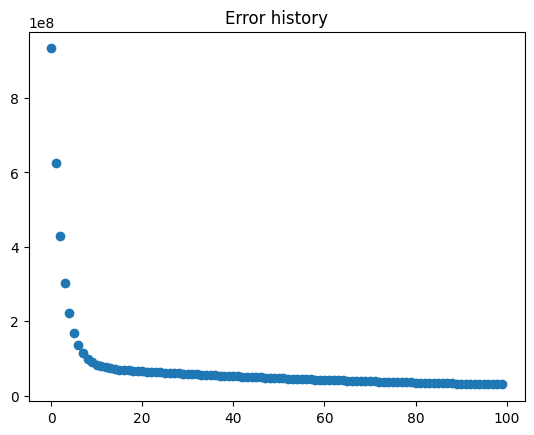

In [ ]:
weights, weight_history, error_history, final_loss = learn(0.00001, 100, 1, housing_train_input, housing_train_output)

print("Weights")
print(weights)


n = 'land'

# Training
plt.scatter(housing_train[n], housing_train["price"])
x_space = np.linspace(np.min(housing_train[n]), np.max(housing_train[n]))
num_weights = weights.shape[1]
model_predictions =  [np.sum(weights * [x ** i for i in range(num_weights)]) for x in x_space]
plt.plot(x_space, model_predictions)
plt.title("Training data with Model")
plt.show()

# Test
plt.scatter(housing_test[n], housing_test["price"])
x_space = np.linspace(np.min(housing_test[n]), np.max(housing_test[n]))
num_weights = weights.shape[1]
model_predictions =  [np.sum(weights * [x ** i for i in range(num_weights)]) for x in x_space]
plt.plot(x_space, model_predictions)
plt.title("Test data with Model")
plt.show()

# Plot history of error
error_history = np.array(error_history)
plt.scatter([i for i in range(0, len(error_history))], error_history)
plt.title(f"Error history")
plt.show()

In [ ]:
data_formats = {'names': ('id', 'baths', 'land', 'living', 'garages', 'rooms','beds','age', 'price'), 'formats':('i2', 'f2', 'f4','f4', 'f4', 'i4', 'i4','i4','f8')}
housing_train = np.loadtxt("train.csv", delimiter=',', skiprows=1, dtype=data_formats)
housing_test = np.loadtxt("test.csv", delimiter=',', skiprows=1, dtype=data_formats)
#House ID,Bathrooms,Land Area,Living area,# Garages,# Rooms,# Bedrooms,Age of home,Price

housing_train_output = housing_train["price"]

# for n in data_formats["names"]:
#     if n == 'price':
#         continue
#     print("\n\n", n)
#     housing_train_input = housing_train[n]

#     weights, weight_history, error_history, final_loss = learn(0.00001, 200, 4, housing_train_input, housing_train_output)


#     plt.scatter(housing_test[n], housing_test["price"])
#     x_space = np.linspace(np.min(housing_test[n]), np.max(housing_test[n]))
#     num_weights = weights.size()
#     model_predictions =  [np.sum(weights * [x ** i for i in range(num_weights)]) for x in x_space]
#     plt.plot(x_space, model_predictions)
#     plt.title("Test data with Model")
#     plt.show()
    
#     # Plot history of error
#     error_history = np.array(error_history)
#     plt.scatter([i for i in range(0, len(error_history))], error_history)
#     plt.title(f"Error history")
#     plt.show()

